In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset"

 BraTS2020_training_data  'BraTS20 Training Metadata.csv'


In [ ]:
!unzip "/content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/archive.zip" -d "/content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data/volume_70_slice_63.h5  
  inflating: /content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data/volume_70_slice_64.h5  
  inflating: /content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data/volume_70_slice_65.h5  
  inflating: /content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data/volume_70_slice_66.h5  
  inflating: /content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data/volume_70_slice_67.h5  
  inflating: /content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data/volume_70_slice_68.h5  
  inflating: /content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data/volume_70_slice_69.h5  
  inflating: /content/drive/MyDrive/DL_Project_Brain_

In [ ]:
!ls "/content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/"

 archive.zip   BraTS2020_training_data	'BraTS20 Training Metadata.csv'


In [ ]:
!ls "/content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data" | head

meta_data.csv
name_mapping.csv
survival_info.csv
volume_100_slice_0.h5
volume_100_slice_100.h5
volume_100_slice_101.h5
volume_100_slice_102.h5
volume_100_slice_103.h5
volume_100_slice_104.h5
volume_100_slice_105.h5


In [ ]:
!pip install h5py

In [ ]:
import os

data_path = "/content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data"

files = os.listdir(data_path)

print("Total files:", len(files))
print(files[:10])

Total files: 57198
['meta_data.csv', 'name_mapping.csv', 'survival_info.csv', 'volume_100_slice_0.h5', 'volume_100_slice_1.h5', 'volume_100_slice_10.h5', 'volume_100_slice_100.h5', 'volume_100_slice_101.h5', 'volume_100_slice_102.h5', 'volume_100_slice_103.h5']


In [ ]:
import h5py

file_path = os.path.join(data_path, files[3])

f = h5py.File(file_path, "r")

print(list(f.keys()))

['image', 'mask']


In [ ]:
image = f['image'][:]
mask = f['mask'][:]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Image shape: (240, 240, 4)
Mask shape: (240, 240, 3)


In [ ]:
combined_mask = (mask[:,:,0] + mask[:,:,1] + mask[:,:,2]) > 0

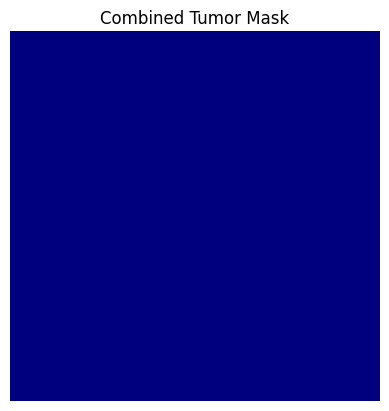

np.int64(0)

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(combined_mask, cmap="jet")
plt.title("Combined Tumor Mask")
plt.axis("off")
plt.show()

combined_mask.sum()

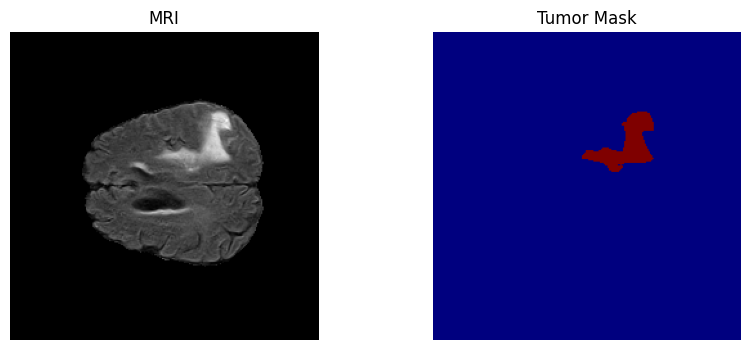

In [ ]:
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

data_path = "/content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data"

files = os.listdir(data_path)

for file in files:

    if not file.endswith(".h5"):
        continue

    f = h5py.File(os.path.join(data_path,file),"r")

    image = f['image'][:]
    mask = f['mask'][:]

    combined_mask = (mask[:,:,0] + mask[:,:,1] + mask[:,:,2]) > 0

    if combined_mask.sum() > 100:

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.imshow(image[:,:,0], cmap="gray")
        plt.title("MRI")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(combined_mask, cmap="jet")
        plt.title("Tumor Mask")
        plt.axis("off")

        plt.show()

        break

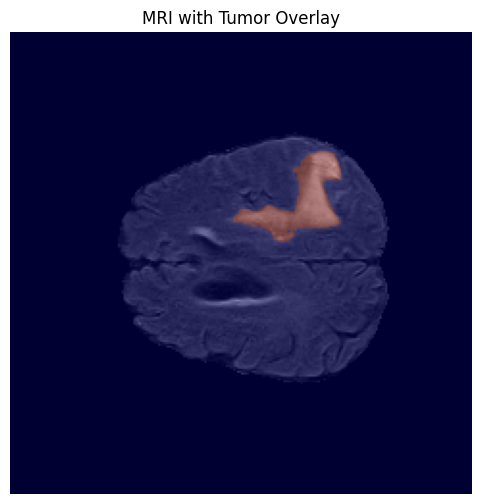

In [ ]:
for file in files:

    if not file.endswith(".h5"):
        continue

    f = h5py.File(os.path.join(data_path,file),"r")

    image = f['image'][:]
    mask = f['mask'][:]

    combined_mask = (mask[:,:,0] + mask[:,:,1] + mask[:,:,2]) > 0

    if combined_mask.sum() > 100:

        plt.figure(figsize=(6,6))
        plt.imshow(image[:,:,0], cmap="gray")
        plt.imshow(combined_mask, cmap="jet", alpha=0.4)
        plt.title("MRI with Tumor Overlay")
        plt.axis("off")
        plt.show()

        break

In [ ]:
# Exploring More For the Specific Analysis
# Basic libraries
import os
import random
import json

# Data handling
import numpy as np
import h5py

# Visualization
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")



In [ ]:
DATA_DIR = "/content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data"

# Get all .h5 files
files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith(".h5")]

print(f"Total files found: {len(files)}")

Total files found: 57195


In [ ]:
sample_file = random.choice(files)

print("Sample file:", sample_file)

with h5py.File(sample_file, "r") as f:
    print("Keys inside file:", list(f.keys()))

    image = f["image"][:]
    mask = f["mask"][:]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image dtype:", image.dtype)
print("Mask unique values:", np.unique(mask))

Sample file: /content/drive/MyDrive/DL_Project_Brain_Tumor/Dataset/BraTS2020_training_data/content/data/volume_141_slice_154.h5
Keys inside file: ['image', 'mask']
Image shape: (240, 240, 4)
Mask shape: (240, 240, 3)
Image dtype: float64
Mask unique values: [0]


# Visualize the dataset sample and tumor

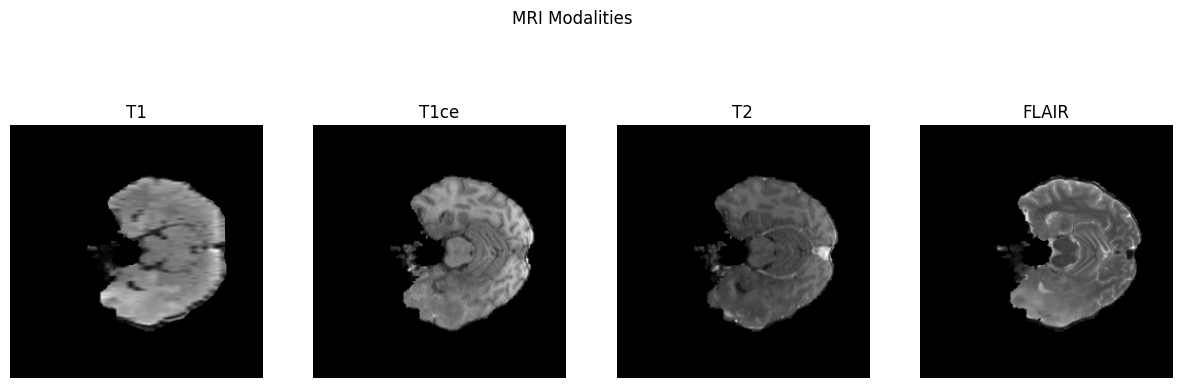

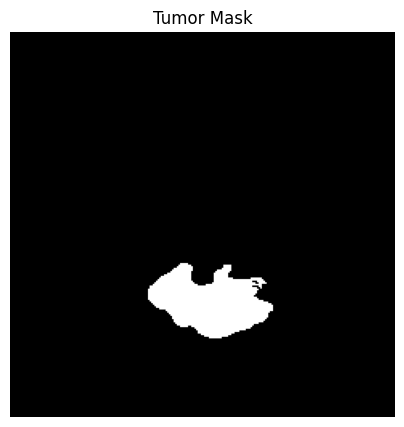

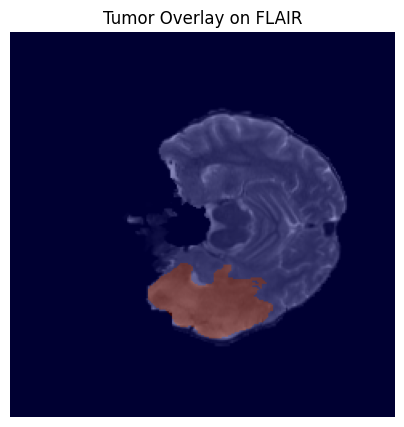

In [ ]:
# Pick a sample file
sample_file = random.choice(files)

with h5py.File(sample_file, "r") as f:
    image = f["image"][:]   # shape: (240, 240, 4)
    mask = f["mask"][:]     # shape: (240, 240, 3)

# Combine mask channels → binary tumor mask
combined_mask = np.sum(mask, axis=-1) > 0

# Titles for modalities
modalities = ["T1", "T1ce", "T2", "FLAIR"]

# Plot all modalities
plt.figure(figsize=(15, 5))

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(image[:, :, i], cmap="gray")
    plt.title(modalities[i])
    plt.axis("off")

plt.suptitle("MRI Modalities")
plt.show()


# Plot mask
plt.figure(figsize=(5,5))
plt.imshow(combined_mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")
plt.show()


# Overlay mask on FLAIR (best for tumor visibility)
plt.figure(figsize=(5,5))
plt.imshow(image[:, :, 3], cmap="gray")  # FLAIR
plt.imshow(combined_mask, cmap="jet", alpha=0.4)
plt.title("Tumor Overlay on FLAIR")
plt.axis("off")
plt.show()

# Tumor Statistics Extraction

In [ ]:
tumor_slices = 0
sample_size = 100  # you can increase later

for file in files[:sample_size]:
    with h5py.File(file, "r") as f:
        mask = f["mask"][:]
        combined_mask = np.sum(mask, axis=-1) > 0

        if combined_mask.sum() > 0:
            tumor_slices += 1

print(f"Tumor slices: {tumor_slices}/{sample_size}")
print(f"Percentage: {(tumor_slices/sample_size)*100:.2f}%")

Tumor slices: 35/100
Percentage: 35.00%


In [ ]:
sample_file = random.choice(files)

with h5py.File(sample_file, "r") as f:
    image = f["image"][:]

print("Intensity Stats:")
print("Min:", np.min(image))
print("Max:", np.max(image))
print("Mean:", np.mean(image))
print("Std:", np.std(image))

Intensity Stats:
Min: -0.6513669152769418
Max: 6.453446526120129
Mean: -2.6645352591003756e-17
Std: 0.9999999999999999


In [ ]:
shapes = set()

for file in files[:50]:
    with h5py.File(file, "r") as f:
        shapes.add(f["image"][:].shape)

print("Unique shapes found:", shapes)

Unique shapes found: {(240, 240, 4)}


In [ ]:
total_files = len(files)
metadata = {
    "total_slices": total_files,
    "sample_checked": sample_size,
    "tumor_slices_in_sample": tumor_slices,
    "tumor_percentage": (tumor_slices/sample_size)*100,
    "image_shape": list(shapes)[0]
}

with open("metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved successfully ✅")

Metadata saved successfully ✅


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'metadata.json', 'sample_data']
